Name :- TANVEER JADAV

Enrollment No. :- 23SOECE11100

Div :- 6CEA

Roll No. :- 39

**Tutorial 4: Implement Decision tree and Naive bayes**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline
user = pd.read_csv("users.csv")

In [3]:
user.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          99 non-null     int64
 1   Gender           99 non-null     str  
 2   Age              99 non-null     int64
 3   EstimatedSalary  99 non-null     int64
 4   Purchased        99 non-null     int64
dtypes: int64(4), str(1)
memory usage: 4.0 KB


In [4]:
user.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [5]:
user.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0


In [6]:
    user['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [7]:
user['Purchased'].unique()

array([0, 1])

In [8]:
user['Age'].min()

np.int64(1)

In [9]:
user['Age'].max()

np.int64(64)

In [10]:
user['EstimatedSalary'].min()

np.int64(15000)

In [11]:
user['EstimatedSalary'].max()

np.int64(150000)

In [12]:
# Selecting predicator attributes
X = user.columns.drop("Purchased")
# Selecting target attribute
y = user["Purchased"]

In [13]:
# Encoding all the predictor variables to convert the categorial values to numerical values
user_encoded = pd.get_dummies(user[X]).astype(int)
# Printing the list of columns after encoding to understand the encoding process

In [14]:
    user_encoded

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,12,19000,0,1
1,15810944,11,20000,0,1
2,15668575,1,43000,1,0
3,15603246,27,57000,1,0
4,15804002,10,76000,0,1
...,...,...,...,...,...
94,15786993,45,83000,1,0
95,15709441,35,44000,1,0
96,15710257,4,25000,1,0
97,15582492,5,123000,0,1


In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(user_encoded,y,test_size=0.15,random_state=0)
print("Shape of X_train and y_train are : ",X_train.shape, "and", y_train.shape, "respectively")
print("Shape of X_test and y_test are : ",X_test.shape, "and", y_test.shape, "respectively")

Shape of X_train and y_train are :  (84, 5) and (84,) respectively
Shape of X_test and y_test are :  (15, 5) and (15,) respectively


In [16]:
from sklearn.tree import DecisionTreeClassifier
# Object 
model = DecisionTreeClassifier(criterion='gini',random_state=1)
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [17]:
train_predictions = model.predict(X_train)
train_predictions = model.predict(X_test)

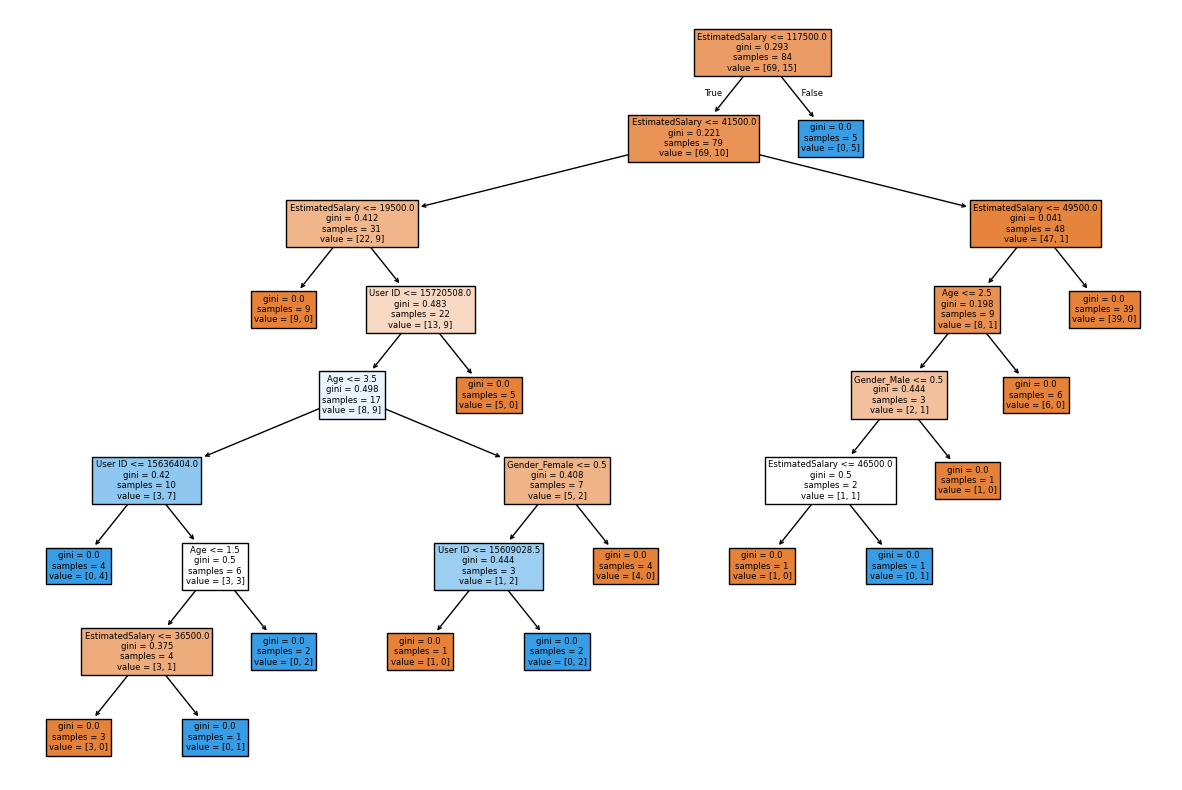

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Generating the tree
plt.figure(figsize=(15,10))
plot_tree(model, feature_names=user_encoded.columns, filled=True)
plt.show()

In [19]:
# Getting the accuracy on train data
train_accuracy = model.score(X_train, y_train)
print("Accuracy of the model on train data = ", train_accuracy)
# Getting the accuracy on test data
test_accuracy = model.score(X_test, y_test)
print("Accuracy of the model on test data = ", test_accuracy)

Accuracy of the model on train data =  1.0
Accuracy of the model on test data =  0.8


**Naive Bayes Classification**

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
iris = load_iris()
X= iris.data
y = iris.target

In [23]:
print("features Names : ",iris.feature_names)
print("Target Names : ",iris.target_names)

features Names :  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names :  ['setosa' 'versicolor' 'virginica']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
X_train.shape

(120, 4)

In [26]:
X_test.shape

(30, 4)

In [27]:
y_train.shape

(120,)

In [28]:
y_test.shape

(30,)

In [29]:
model = GaussianNB()
model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [30]:
y_pred = model.predict(X_test)

In [31]:
print("Accuracy : ", accuracy_score(y_test,y_pred))

Accuracy :  1.0


In [32]:
print("Classification Report :\n", classification_report(y_test, y_pred))

Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [33]:
print("confusion Matrix : \n", confusion_matrix(y_test,y_pred))

confusion Matrix : 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Text(50.722222222222214, 0.5, 'Actual')

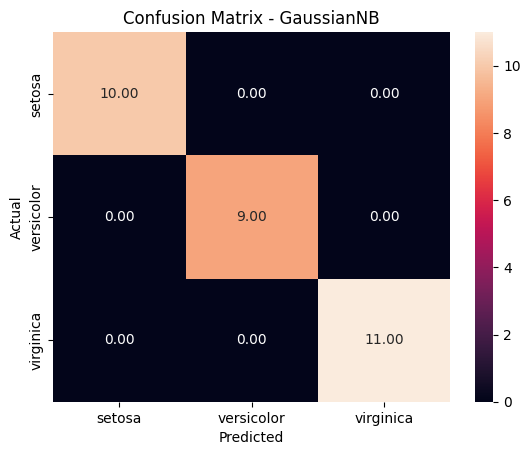

In [34]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.2f', xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.title("Confusion Matrix - GaussianNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")

Exercise 3: Bagging and Boosting

1. we are going to work on spambase dataset, where the normalized frequency of different words in an email are recorded, based on which an email is labeled as spam (1) or not spam (0)

2. Read dataset “spambase.csv”.

3. Split the data into a train and test set.

4. Implement Bagging using Random Forest Algorithm.

5. Implement Boosting using Adaboost Algorithm.

In [35]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import accuracy_score, classification_report
warnings.filterwarnings("ignore")

In [36]:
spam_data = pd.read_csv("spambase.csv")

In [37]:
spam_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_req_our                4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [38]:
spam_data.isna().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_req_our                  0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [39]:
spam_data.head(10)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
5,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1
6,0.00,0.00,0.00,0.0,1.92,0.00,0.00,0.00,0.00,0.64,...,0.00,0.054,0.0,0.164,0.054,0.000,1.671,4,112,1
7,0.00,0.00,0.00,0.0,1.88,0.00,0.00,1.88,0.00,0.00,...,0.00,0.206,0.0,0.000,0.000,0.000,2.450,11,49,1
8,0.15,0.00,0.46,0.0,0.61,0.00,0.30,0.00,0.92,0.76,...,0.00,0.271,0.0,0.181,0.203,0.022,9.744,445,1257,1
9,0.06,0.12,0.77,0.0,0.19,0.32,0.38,0.00,0.06,0.00,...,0.04,0.030,0.0,0.244,0.081,0.000,1.729,43,749,1


In [40]:
from sklearn.model_selection import train_test_split
features = spam_data.columns.drop('spam')
target = 'spam'
X = spam_data[features]
Y = spam_data[target]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=100)

In [41]:
X = spam_data.iloc[:,:-1]
Y = spam_data.iloc[:,-1]

In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=100)

In [43]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=10,min_samples_split=20,min_impurity_decrease=0.05)
model.fit(X_train,Y_train)
train_accuracy = model.score(X_train, Y_train)
print("Accuracy on training data: ", train_accuracy)    
test_accuracy = model.score(X_test, Y_test)
print("Accuracy on testing data: ", test_accuracy)

Accuracy on training data:  0.847554347826087
Accuracy on testing data:  0.8349619978284474


In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=10)
model.fit(X_train,Y_train)
train_accuracy = model.score(X_train,Y_train)
test_accuracy = model.score(X_test,Y_test)
print(train_accuracy,test_accuracy)

0.9067934782608695 0.9131378935939196
